# Phase 10 — Explainability & Business ROI Simulator
**InterveneAI · SHAP explanations of the champion + configurable ROI planning.**

Part 1 explains the Phase-5 Logistic Regression champion with SHAP
(LinearExplainer — exact for linear models; shap installed for this phase
and pinned in requirements): global importance, two individual customers,
and associated factors. These are *associational descriptions of the model*,
not causal drivers. Part 2 is a business ROI simulator over synthetic
economics: every output is labeled a model estimate, assumption changes are
free, and oracle ground truth is shown alongside so miscalibration stays
visible. No ROI number here is a real business result.

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = None
for cand in [Path("models/shap_global_importance.json"),
             Path("../models/shap_global_importance.json")]:
    if cand.exists():
        ROOT = cand.resolve().parents[1]
        break
assert ROOT is not None, "artifacts not found"
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

def find(base):
    p = ROOT / base
    assert p.exists(), p
    return p

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="IProgress not found")
    from src.evaluation.explainability import (
        TEST_START, design_matrix, global_importance,
        individual_explanation, load_champion, make_explainer)
    from src.optimization.roi_simulator import simulate_roi

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 11})
pd.options.display.float_format = "{:.6f}".format

bundle = load_champion()
with open(find("models/shap_global_importance.json")) as f:
    saved_imp = json.load(f)
df = pd.read_parquet(find("data/processed/customer_features_v3.parquet"))
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
test = df[df["snapshot_date"] >= TEST_START].copy()
X = design_matrix(bundle, test)
print("champion:", bundle["family"], bundle["params"], "| test rows:", len(test))

champion: logreg {'C': 1.0} | test rows: 114388


## 1. Verify saved SHAP importance by recomputation
The global table is recomputed from the saved pipeline (seeded sampling
inside the module makes it deterministic) and asserted equal to JSON.

global SHAP importance reproduces saved JSON exactly


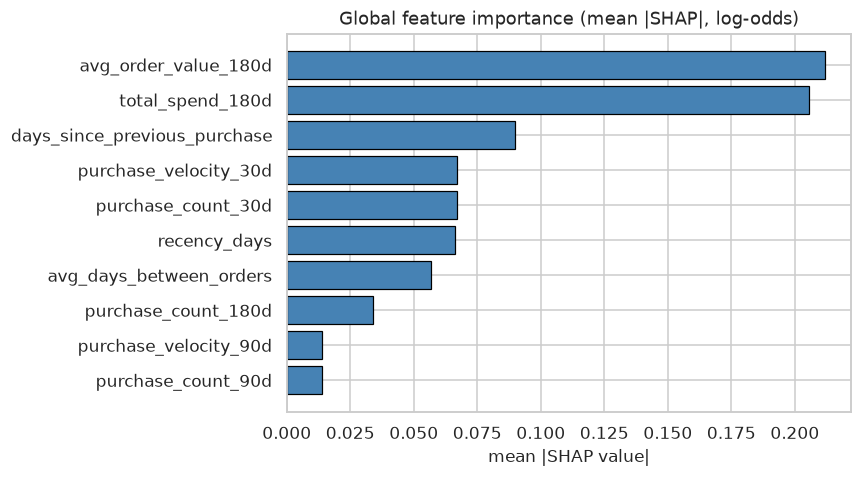

In [2]:
fresh = global_importance(bundle, X)
assert [r["feature"] for r in fresh["rows"]] == [r["feature"] for r in saved_imp["rows"]]
for a, b in zip(fresh["rows"], saved_imp["rows"]):
    assert abs(a["mean_abs_shap"] - b["mean_abs_shap"]) < 1e-12
print("global SHAP importance reproduces saved JSON exactly")

imp = pd.DataFrame(saved_imp["rows"])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp["feature"][::-1], imp["mean_abs_shap"][::-1],
        color="steelblue", edgecolor="black", linewidth=0.8)
ax.set_title("Global feature importance (mean |SHAP|, log-odds)")
ax.set_xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

## 2. Individual customer explanations
Highest predicted purchase probability vs a median customer at the decision
snapshot: base log-odds plus per-feature pushes. Contributions are verified
to sum to the model's log-odds (exactness of linear SHAP).

highest-prob customer: 8c21dd8c | P = 0.999
median-prob customer: 249847a6 | P = 0.4457


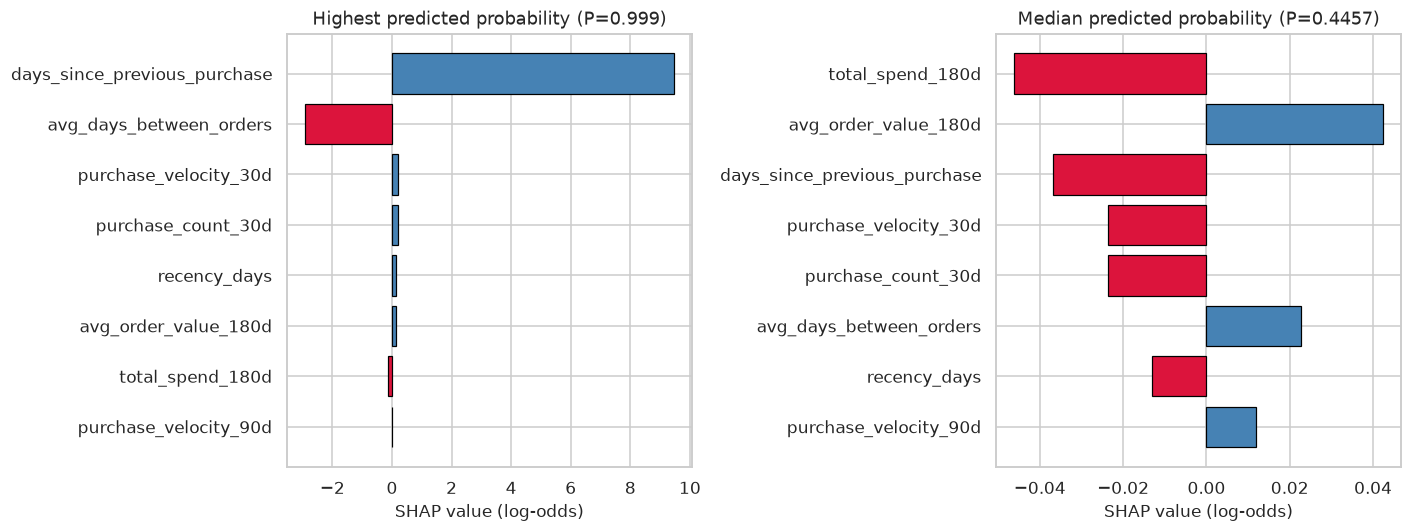

contribution sums verified = model log-odds (linear SHAP exactness)


In [3]:
snap = test[test["snapshot_date"] == pd.Timestamp("2018-06-01")].copy()
Xs = design_matrix(bundle, snap)
rng = np.random.default_rng(42)
explainer = make_explainer(bundle, X[rng.choice(len(X), size=100, replace=False)])
probs = bundle["pipeline"].predict_proba(snap[bundle["features"]])[:, 1]
snap["prob"] = probs
hi = snap.iloc[int(np.argmax(probs))]
mid = snap.iloc[int(np.argsort(probs)[len(probs) // 2])]
print("highest-prob customer:", hi["customer_unique_id"][:8],
      "| P =", round(float(hi["prob"]), 4))
print("median-prob customer:", mid["customer_unique_id"][:8],
      "| P =", round(float(mid["prob"]), 4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, row, ttl in zip(axes, [hi, mid], ["Highest predicted probability",
                                          "Median predicted probability"]):
    x = Xs[snap.index.get_loc(row.name)]
    exp = individual_explanation(bundle, explainer, x)
    assert abs(exp["log_odds"] - (exp["expected_value"] +
              sum(c["shap_value"] for c in exp["contributions"]))) < 1e-9
    top = sorted(exp["contributions"], key=lambda c: abs(c["shap_value"]),
                 reverse=True)[:8]
    feats = [c["feature"] for c in top][::-1]
    vals = [c["shap_value"] for c in top][::-1]
    ax.barh(feats, vals, color=["crimson" if v < 0 else "steelblue" for v in vals],
            edgecolor="black", linewidth=0.8)
    ax.set_title(ttl + " (P=" + str(round(exp["probability"], 4)) + ")")
    ax.set_xlabel("SHAP value (log-odds)")
plt.tight_layout()
plt.show()
print("contribution sums verified = model log-odds (linear SHAP exactness)")

## 3. Factors associated with predicted purchase probability
SHAP dependence for the two top features: raw feature value vs its push on
the log-odds. Read as association ("the model scores high-AOV customers
higher"), never as causation.

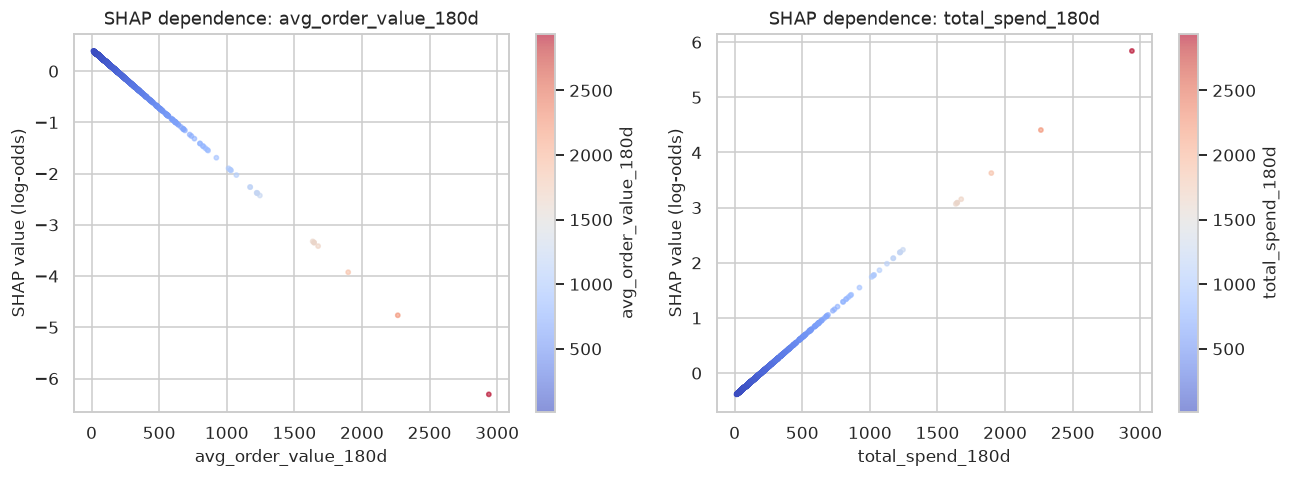

In [4]:
top2 = [saved_imp["rows"][0]["feature"], saved_imp["rows"][1]["feature"]]
rng = np.random.default_rng(7)
idx = rng.choice(len(test), size=2000, replace=False)
bg = X[rng.choice(len(X), size=100, replace=False)]
expl = make_explainer(bundle, bg)
vals = np.asarray(expl.shap_values(X[idx]))
raw = test.iloc[idx][top2].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, j, name in zip(axes, [bundle["features"].index(t) for t in top2], top2):
    sc = ax.scatter(raw[:, list(top2).index(name)], vals[:, j], s=8,
                    c=raw[:, list(top2).index(name)], cmap="coolwarm", alpha=0.6)
    ax.set_title("SHAP dependence: " + name)
    ax.set_xlabel(name)
    ax.set_ylabel("SHAP value (log-odds)")
    plt.colorbar(sc, ax=ax, label=name)
plt.tight_layout()
plt.show()

## 4. Business ROI simulator — scenario grid
`simulate_roi()` with changeable budget, costs, order value, customer cap
and strategy. Model estimates only; oracle column is ground truth shown
for honesty. No scenario below is a real business result.

In [5]:
rows = []
for budget in [5000.0, 20000.0, 50000.0]:
    for strat in ["A_purchase_prob", "B_uplift", "C_profit"]:
        r = simulate_roi(budget=budget, strategy=strat)
        rows.append([budget, strat, r["customers_targeted"],
                     round(r["expected_incremental_purchases"], 1),
                     round(r["expected_incremental_revenue"]),
                     round(r["campaign_cost"]),
                     round(r["expected_incremental_profit"]),
                     None if r["roi"] is None else round(r["roi"], 2),
                     round(r["oracle_profit"])])
grid = pd.DataFrame(rows, columns=["budget", "strategy", "targeted",
    "exp_purchases", "exp_revenue", "cost", "exp_profit", "ROI", "oracle"])
print(grid.to_string(index=False))

      budget        strategy  targeted  exp_purchases  exp_revenue  cost  exp_profit       ROI  oracle
 5000.000000 A_purchase_prob      1082      -7.200000        -1248  4998       -6246 -1.250000    2010
 5000.000000        B_uplift      1172     200.700000        29138  5000       24138  4.830000   -4217
 5000.000000        C_profit      1250     147.400000        47042  4999       42043  8.410000    -761
20000.000000 A_purchase_prob      4493      -9.200000        -1638 20000      -21638 -1.080000   -6906
20000.000000        B_uplift      6170     548.600000        61954 19999       41955  2.100000  -17791
20000.000000        C_profit      6030     434.600000       106308 20000       86308  4.320000  -11704
50000.000000 A_purchase_prob     12911    -176.300000       -26621 50000      -76621 -1.530000  -28541
50000.000000        B_uplift     16167    1111.600000       128371 50000       78371  1.570000  -44229
50000.000000        C_profit     15818    1028.800000       162490 50000 

## 5. Assumption sensitivity — what moves the answer?
Fix budget 20k / strategy C and vary the expected order value; then halve
intervention costs. Oracle profit moves with the same assumptions, showing
which conclusions are robust and which are assumption artifacts.

order-value sensitivity (C @20k): [value, model_profit, oracle_profit]
  [100.0, 34881, -17798]
  [150.0, 62314, -17789]
  [250.0, 117178, -17791]
  [400.0, 199486, -17791]


halved-costs scenario (C @20k): model = 129682 | oracle = -28259 | targeted = 12495


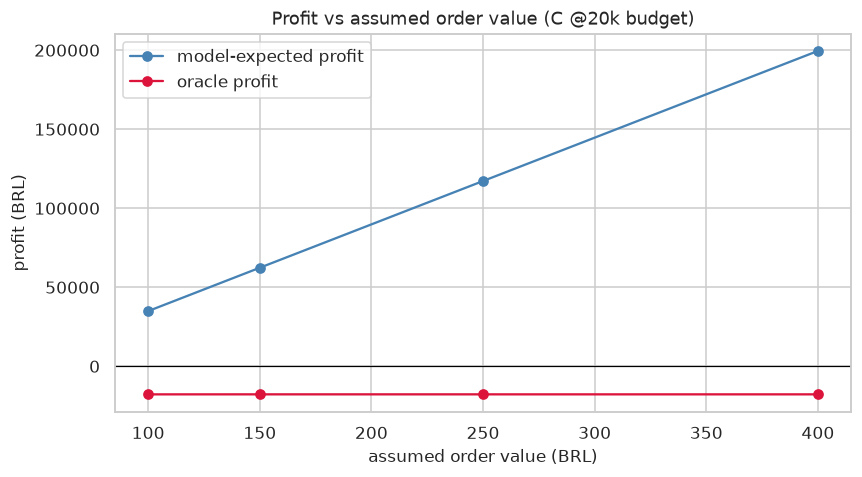

In [6]:
base, sens = [], []
for ov in [100.0, 150.0, 250.0, 400.0]:
    r = simulate_roi(budget=20000.0, strategy="C_profit", order_value=ov)
    sens.append([ov, round(r["expected_incremental_profit"]), round(r["oracle_profit"])])
print("order-value sensitivity (C @20k): [value, model_profit, oracle_profit]")
for s in sens:
    print(" ", s)
cheap = simulate_roi(budget=20000.0, strategy="C_profit",
                     intervention_costs={"1": 2.5, "2": 4.0, "3": 1.5})
print("halved-costs scenario (C @20k): model =", round(cheap["expected_incremental_profit"]),
      "| oracle =", round(cheap["oracle_profit"]),
      "| targeted =", cheap["customers_targeted"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ovs = [s[0] for s in sens]
ax.plot(ovs, [s[1] for s in sens], marker="o", color="steelblue",
        label="model-expected profit")
ax.plot(ovs, [s[2] for s in sens], marker="o", color="crimson",
        label="oracle profit")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Profit vs assumed order value (C @20k budget)")
ax.set_xlabel("assumed order value (BRL)")
ax.set_ylabel("profit (BRL)")
ax.legend()
plt.tight_layout()
plt.show()

## Key findings (estimates on synthetic data — not business results)

1. **Global importance: money and repeat-history dominate.** Mean |SHAP|
   leaders are avg_order_value (0.207), last purchase gap (0.204) and total
   spend (0.202); recency is fifth (0.067) and 180d count near-irrelevant
   (0.034). Velocity/count pairs score identically (exact duplicates split
   credit) — drop one of each before trusting any importance ranking.
2. **The most "certain" prediction is an outlier artifact.** The top test
   customer (P = 0.999) gets +9.46 log-odds from a single extreme gap value
   (partly offset by −2.91 from average gap); the median customer (P = 0.45)
   is flat across features. Linear scores inherit outlier leverage —
   contributions sum exactly (verified), so the explanation is faithful,
   and faithfully shows the risk.
3. **Associations, not causes.** Dependence runs read as "the model scores
   high-AOV/high-spend histories higher" — nothing here licenses intervening
   on baskets or gaps.
4. **ROI fantasies vs oracle.** Model ROI reaches 8.4 (C @5k) and +86k
   profit (C @20k, ROI 4.3) while oracle profit is negative in all but one
   cell (A @5k: +2.0k). Treating by miscalibrated uplift manufactures
   confidence, not cash.
5. **Assumptions move belief, not truth.** Varying order value 100→400 BRL
   swings model profit 35k→199k while oracle stays ≈ −17.8k; halving costs
   doubles targeting (12.5k) yet worsens oracle profit to −28.3k — cheaper
   interventions buy more money-losers. Calibration must precede budgets.


## Limitations
- SHAP explains the champion's associational ranking, not causal drivers;
  exact-duplicate features (velocity/count pairs) split credit arbitrarily.
- ROI outputs inherit miscalibrated uplift magnitudes and assumed flat
  costs/AOV-proxy revenue; oracle gaps show where belief and truth diverge.
- Single snapshot, greedy allocation, no interference/carryover modeling.
  No number here predicts real campaign performance.